# Customer Churn Prediction

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [30]:
df=pd.read_csv("customer_churn_dataset/customer_churn_dataset-training-master.csv")
print(df.head())
df.info()
df.describe()


   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


# Columns are mapped in order to match the required fields this is called the Feature Mapping 

Total spend represents the customer's financial contribution and used instead of income.

Usage Frequency that is higher usage indicates more engagement which is similar to purchases.

Subscription Type contains categories like Basic,standard and Premium represents different membership levels.

In [31]:
df=df[['Age','Total Spend','Usage Frequency','Subscription Type','Churn']]
df.columns=['Age', 'Income', 'Purchases', 'Membership', 'Churn']
df.head()

,Age,Income,Purchases,Membership,Churn
0,30.0,932.0,14.0,Standard,1.0
1,65.0,557.0,1.0,Basic,1.0
2,55.0,185.0,4.0,Basic,1.0
3,58.0,396.0,21.0,Standard,1.0
4,23.0,617.0,20.0,Basic,1.0


In [32]:
df.isnull().sum()
df.dropna(inplace=True)

# One-hot encoding is applied to convert categorical data into numerical form 

Membership column-Basic,Standard and Premium so these were converted to numerical values.

'drop_first=True' was used to avoid unneccessary duplicate values and makes model simple.



In [33]:
df=pd.get_dummies(df,columns=['Membership'],drop_first=True)

In [34]:
from sklearn.model_selection import train_test_split

X=df.drop('Churn', axis=1)
y=df['Churn']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Class Distribution
The distribution of target variable was analyzed based on percentage values

In [35]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64

Class Imbalance handling is not required as there is no significant imbalance

# Feature Scaling 

Feature Scaling is done using StandardScaler to bring all input features to same range called normalizing. This helps to improve performance of Logistic Regression.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [47]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=2000,
                            C=0.5)
model1.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [48]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(
    max_depth=5,min_samples_split=10,
    random_state=42
)
model2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [49]:
from sklearn.ensemble import RandomForestClassifier


model3 = RandomForestClassifier(n_estimators=300,max_depth=12,
                                min_samples_split=4,min_samples_leaf=2,
                                random_state=42)
model3.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Both Decision Tree and Random forest were used in order to compare how a simple interpretable model and a more stable model works.

In [58]:
from sklearn.ensemble import GradientBoostingClassifier

model4 = GradientBoostingClassifier(n_estimators =200,learning_rate=0.05,
max_depth=3,random_state=42)
model4.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


for ensemble learning gradient boosting method was used to improve performance by combining several weak learners.

# For Model Improvement hyper parameter tuning was done

In [51]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model3, X, y, cv=5)
print("RF CV Accuracy:", scores.mean())


RF CV Accuracy: 0.7994156539612037


Random Forest is complex ensemble model so to evaluate its stability and to ensure it performs consistently across different data splits Cross Validation was performed on it.

In [60]:
from sklearn.metrics import accuracy_score

train_pred1 = model1.predict(X_train)
train_pred2 = model2.predict(X_train)
train_pred3 = model3.predict(X_train)
train_pred4 = model4.predict(X_train)

train_acc1 = accuracy_score(y_train, train_pred1)
train_acc2 = accuracy_score(y_train, train_pred2)
train_acc3 = accuracy_score(y_train, train_pred3)
train_acc4 = accuracy_score(y_train, train_pred4)

print("Logistic Regression: Train =", train_acc1)
print("Decision Tree: Train =", train_acc2)
print("Random Forest: Train =", train_acc3)
print("Gradient Boosting: Train =", train_acc4)

Logistic Regression: Train = 0.679667673287681
Decision Tree: Train = 0.7996767470545701
Random Forest: Train = 0.8034083336877773
Gradient Boosting: Train = 0.801984886507025


In [61]:
from sklearn.metrics import accuracy_score

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)
pred4 = model4.predict(X_test)

acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)
acc3 = accuracy_score(y_test, pred3)
acc4 = accuracy_score(y_test, pred4)

print("Logistic Regression Accuracy:", acc1)
print("Decision Tree Accuracy:", acc2)
print("Random Forest Accuracy:", acc3)
print("Gradient Boosting Accuracy:", acc4)

Logistic Regression Accuracy: 0.6808896752753297
Decision Tree Accuracy: 0.7978381934283802
Random Forest Accuracy: 0.7983372463620175
Gradient Boosting Accuracy: 0.8005035897784886


# Overfitting Analysis

the models were evaluated on both training and testing datasets while comparing their accuracies overall they showed similar accuracies only.

# Model evaluation using Precision,Recall, and F1 score

In [70]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, pred1))

print("Decision Tree")
print(classification_report(y_test, pred2))

print("Random Forest")
print(classification_report(y_test, pred3))

print("Gradient Boosting")
print(classification_report(y_test, pred4))

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.63      0.62      0.63     38063
         1.0       0.72      0.73      0.72     50104

    accuracy                           0.68     88167
   macro avg       0.67      0.67      0.67     88167
weighted avg       0.68      0.68      0.68     88167

Decision Tree
              precision    recall  f1-score   support

         0.0       0.68      0.99      0.81     38063
         1.0       0.99      0.65      0.79     50104

    accuracy                           0.80     88167
   macro avg       0.84      0.82      0.80     88167
weighted avg       0.86      0.80      0.80     88167

Random Forest
              precision    recall  f1-score   support

         0.0       0.68      0.99      0.81     38063
         1.0       0.99      0.65      0.79     50104

    accuracy                           0.80     88167
   macro avg       0.84      0.82      0.80     88167
weighted avg       0.86   

The models were evaluated using precion,recall,f1-score.

Logistic regression has less f1-score which shows it is less effective in capturing patterns when they are complex,whereas other models showed higher performance with f1-score around 0.80.

For class 0(non-churn),the recall is high around 0.99 which indicated they are good at identifying non-churn customers.
For class 1(churn),the recall is low which means they miss out some churn cases but has high precision which means if model predicts churn it is usually correct.

# Model Comparison

Bar chart used to compare model accuracies

TypeError: show() got an unexpected keyword argument 'cmap'

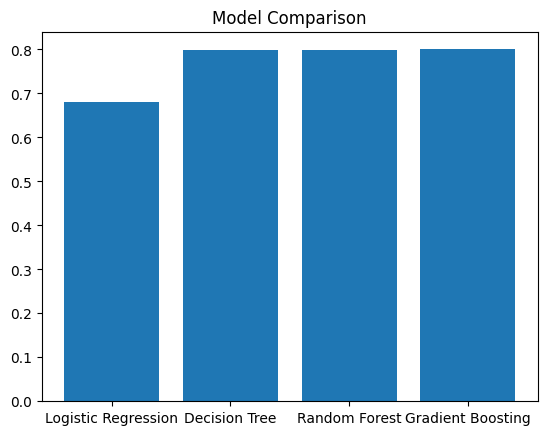

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
accuracy = [acc1, acc2, acc3, acc4]
plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show(cmap='Pink')

# Confusion Matrix

They help to identify correct pedictions and the error made by the model by showing how the model predicts churn and non-churn

# Model Visualization

I have applied certain visualization techniques only to Gradient Boosting model as it performs better compared to other models.

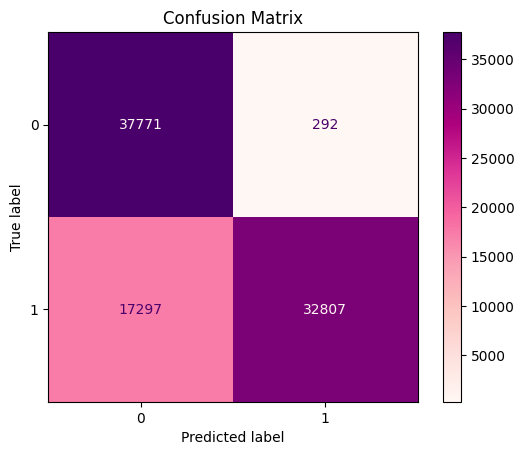

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred4)  
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='RdPu')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve

This ROC curve was used to see how the model differentiates between churn and non-churn customers.higher AUC value denotes better classification performance.

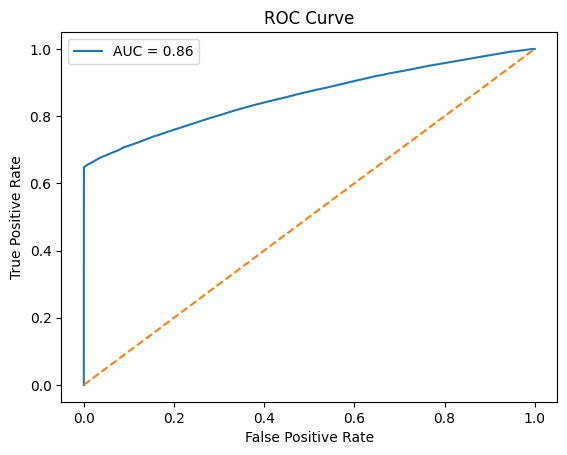

In [76]:
from sklearn.metrics import roc_curve, auc

y_prob = model4.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature Importance 

This helps to understand which variable highly influence on churn prediction which helps to analyze customer behaviour.


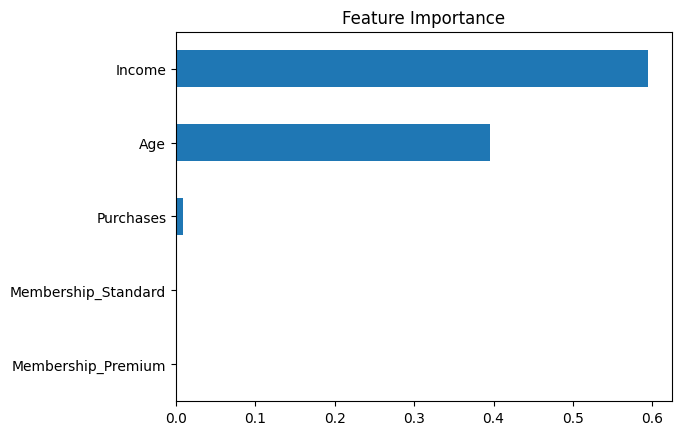

In [ ]:
feature_importance = pd.Series(model4.feature_importances_, index=X.columns)

feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

# Feature Correlation

This heatmap was used to show the relationships between features which helps to understand dependencies and patterns underlying in the dataset.

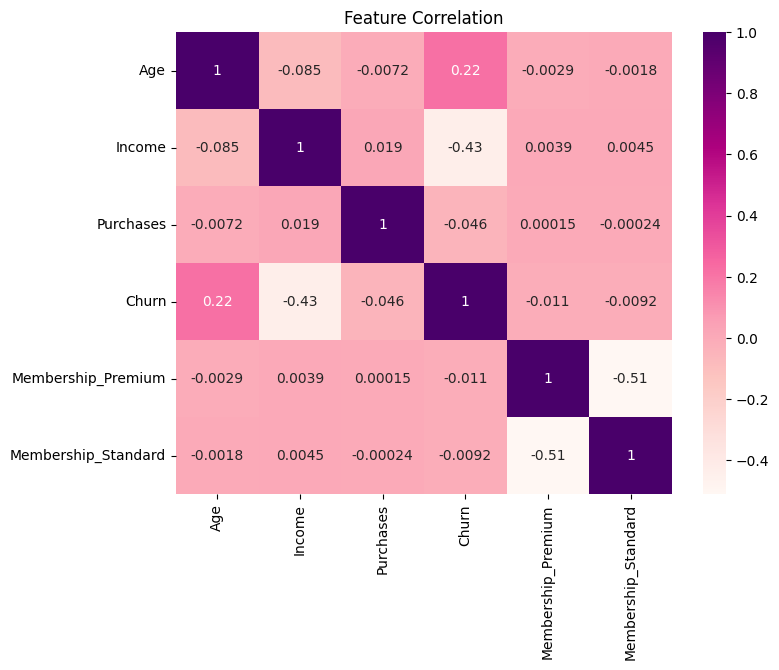

In [77]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='RdPu')
plt.title("Feature Correlation")
plt.show()

In [68]:
def churn_rule(purchases, membership_basic):
    if purchases < 5 and membership_basic == 1:
        return 1
    return 0